# 🌍 Notebook 1: Early Warning System Architecture Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digihaz/early-warning-system-workshop/blob/main/notebooks/01_ews_system_architecture_demo.ipynb)
**DigiHaz Doctoral Training Programme — Module 5: Early Warning System Design**

---

This notebook demonstrates the **complete EWS data pipeline** from seismic sensor detection to user alert dissemination.

You will:
1. Simulate a sensor network detecting P-waves from an earthquake
2. Watch magnitude estimation improve as more stations report
3. Trigger an alert and calculate warning times by distance
4. Visualise the race between the alert signal and the damaging S-wave

**No prior coding knowledge required** — run each cell with `Shift+Enter` and read the explanations.

---

## Setup: Install and import libraries

In [1]:
# ✅ All libraries below come pre-installed on Google Colab — this cell is a safety check
# If running locally, this will install any missing packages
import importlib, subprocess, sys
needed = ['matplotlib', 'numpy', 'pandas']
for pkg in needed:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All libraries ready')

✅ All libraries ready


---
## Part 1 — The EWS Data Pipeline

Every Early Warning System, regardless of hazard type, passes data through **5 functional layers**:

| Layer | What it does | Speed |
|-------|-------------|-------|
| **Sensors** | Detect physical signal (seismic, rainfall, GPS) | Continuous |
| **Processing** | Estimate magnitude, intensity, location | Milliseconds |
| **Decision** | Compare to threshold, assign alert level | < 1 second |
| **Dissemination** | Broadcast via SMS, app, sirens, TV | 1–5 seconds |
| **Response** | People take protective action | Seconds–minutes |

Run the cell below to visualise this pipeline:

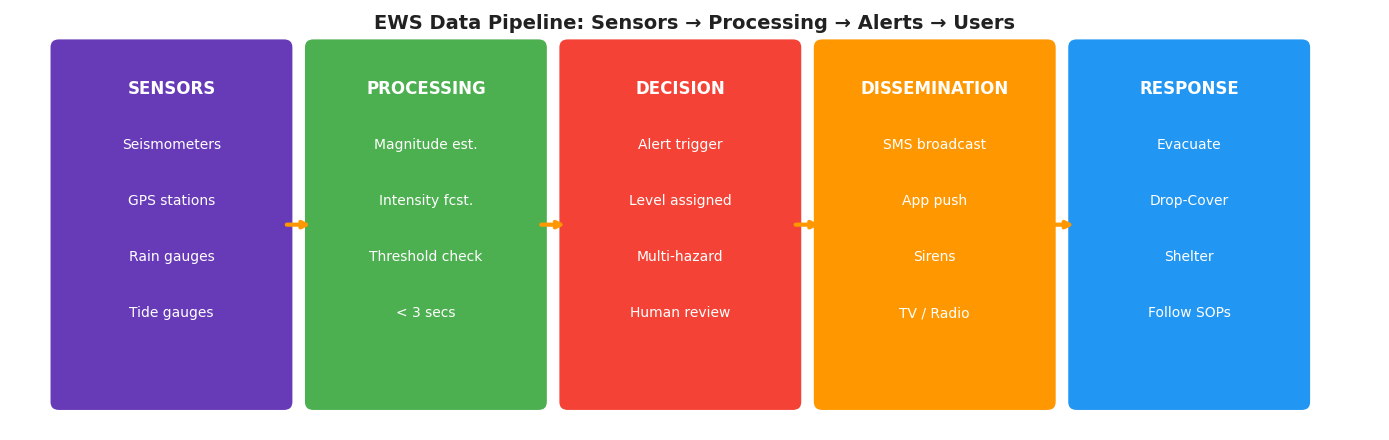

The pipeline has 5 layers. Failure in ANY layer can break the whole warning chain.


In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Define colours
PURPLE = '#673ab7'
GREEN  = '#4caf50'
RED    = '#f44336'
ORANGE = '#ff9800'
BLUE   = '#2196f3'
DARK   = '#212121'

fig, ax = plt.subplots(figsize=(14, 4.5), facecolor='white')
ax.set_xlim(0, 14); ax.set_ylim(0, 4.5); ax.axis('off')

steps = [
    ('SENSORS',       'Seismometers\nGPS stations\nRain gauges\nTide gauges',        PURPLE, 0.5),
    ('PROCESSING',    'Magnitude est.\nIntensity fcst.\nThreshold check\n< 3 secs',  GREEN,  3.1),
    ('DECISION',      'Alert trigger\nLevel assigned\nMulti-hazard\nHuman review',   RED,    5.7),
    ('DISSEMINATION', 'SMS broadcast\nApp push\nSirens\nTV / Radio',                 ORANGE, 8.3),
    ('RESPONSE',      'Evacuate\nDrop-Cover\nShelter\nFollow SOPs',                  BLUE,   10.9),
]

for label, detail, col, x in steps:
    rect = FancyBboxPatch((x, 0.3), 2.3, 3.8, boxstyle='round,pad=0.1',
                          facecolor=col, edgecolor='white', lw=2)
    ax.add_patch(rect)
    ax.text(x+1.15, 3.65, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')
    for i, line in enumerate(detail.split('\n')):
        ax.text(x+1.15, 3.05-i*0.6, line, ha='center', va='center',
                fontsize=10, color='white')
    if x < 10.9:
        ax.annotate('', xy=(x+2.3+0.3, 2.2), xytext=(x+2.3, 2.2),
                    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=3))

ax.text(7, 4.3, 'EWS Data Pipeline: Sensors → Processing → Alerts → Users',
        ha='center', fontsize=14, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('ews_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('The pipeline has 5 layers. Failure in ANY layer can break the whole warning chain.')

---
## Part 2 — Simulating a Seismic Sensor Network

An earthquake generates two types of seismic waves:
- **P-waves (primary)**: travel at ~6 km/s — arrive first, less damaging
- **S-waves (shear)**: travel at ~3.5 km/s — arrive second, much more damaging

The EWS detects the P-wave at the nearest stations and issues an alert **before** the S-wave arrives at more distant locations.

**Try changing the earthquake magnitude and see what happens to the alert zone:**

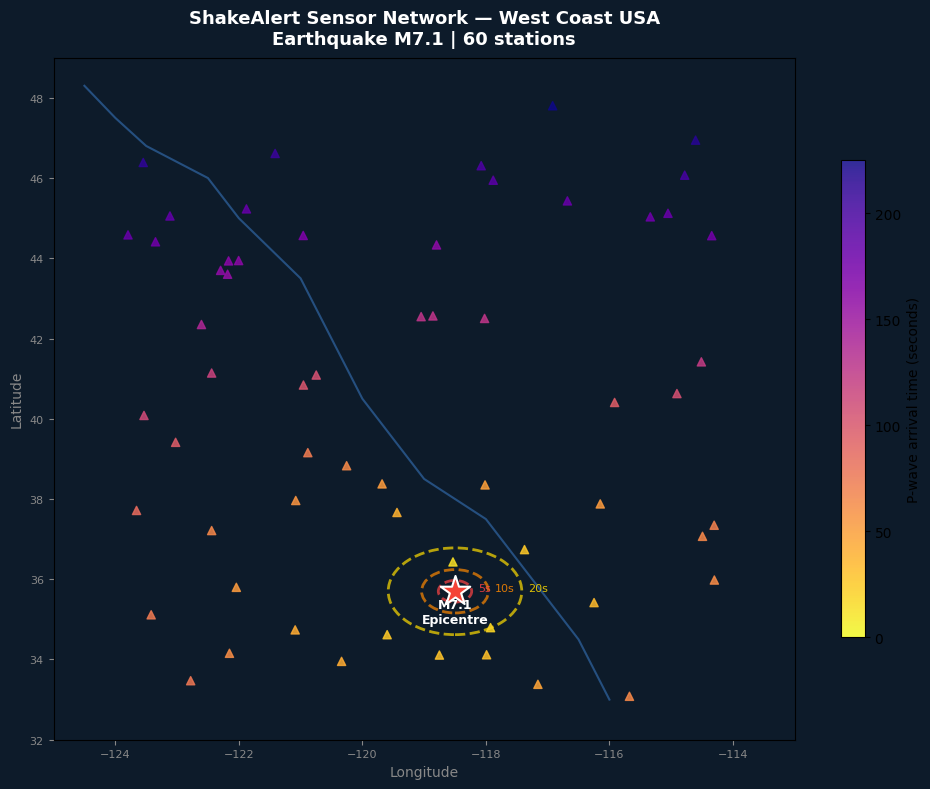

Earthquake M7.1 at (35.7°N, -118.5°W)
Closest station: 81.3 km → P-wave arrives in 13.6 seconds
Stations within 50 km: 0
Stations within 100 km: 1


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ── PARAMETERS: Change these and re-run the cell ─────────────────────────
EARTHQUAKE_MAGNITUDE = 7.1     # Try: 5.0, 6.0, 7.1, 8.0
N_STATIONS           = 60      # Number of seismic stations
# ─────────────────────────────────────────────────────────────────────────

np.random.seed(42)
sta_lons = np.random.uniform(-124, -114, N_STATIONS)
sta_lats = np.random.uniform(33, 48, N_STATIONS)
epi_lon, epi_lat = -118.5, 35.7   # Ridgecrest, CA area

# Distance from epicentre to each station (km)
distances_km = np.sqrt(((sta_lons - epi_lon)*111*np.cos(np.radians(epi_lat)))**2 +
                       ((sta_lats - epi_lat)*111)**2)

# P-wave arrival time at each station
P_WAVE_SPEED = 6.0   # km/s
p_arrival = distances_km / P_WAVE_SPEED

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0d1b2a')
ax.set_facecolor('#0d1b2a')
ax.set_xlim(-125, -113); ax.set_ylim(32, 49)

# Coast approximation
coast_lon = [-124.5,-124,-123.5,-122.5,-122,-121,-120,-119,-118,-117.5,-117,-116.5,-116]
coast_lat = [48.3,   47.5, 46.8,  46.0,  45.0, 43.5, 40.5, 38.5, 37.5,  36.5,  35.5, 34.5, 33.0]
ax.plot(coast_lon, coast_lat, color='#4a9eff', lw=1.5, alpha=0.4)

# Colour stations by P-wave arrival time
sc = ax.scatter(sta_lons, sta_lats, c=p_arrival, cmap='plasma_r',
                s=35, alpha=0.85, zorder=4, marker='^',
                vmin=0, vmax=p_arrival.max())
plt.colorbar(sc, ax=ax, label='P-wave arrival time (seconds)', shrink=0.7)

# Epicentre
ax.scatter(epi_lon, epi_lat, s=500, c='#f44336', marker='*', zorder=6,
           edgecolors='white', lw=1.5)
ax.text(epi_lon, epi_lat-0.8, f'M{EARTHQUAKE_MAGNITUDE}\nEpicentre',
        ha='center', fontsize=9, color='white', fontweight='bold')

# P-wave rings at 5, 10, 20 seconds
for t_s, col in [(5,'#ff4444'),(10,'#ff8800'),(20,'#ffdd00')]:
    r_deg = (P_WAVE_SPEED * t_s) / 111
    circle = plt.Circle((epi_lon, epi_lat), r_deg, fill=False,
                         edgecolor=col, lw=2, alpha=0.7, ls='--')
    ax.add_patch(circle)
    ax.text(epi_lon + r_deg + 0.1, epi_lat, f'{t_s}s',
            fontsize=8, color=col, alpha=0.85)

ax.set_title(f'ShakeAlert Sensor Network — West Coast USA\nEarthquake M{EARTHQUAKE_MAGNITUDE} | {N_STATIONS} stations',
             fontsize=13, color='white', fontweight='bold', pad=10)
ax.tick_params(colors='#888', labelsize=8)
ax.set_xlabel('Longitude', color='#888'); ax.set_ylabel('Latitude', color='#888')
plt.tight_layout()
plt.show()

# Stats
closest = distances_km.min()
print(f'Earthquake M{EARTHQUAKE_MAGNITUDE} at ({epi_lat:.1f}°N, {epi_lon:.1f}°W)')
print(f'Closest station: {closest:.1f} km → P-wave arrives in {closest/P_WAVE_SPEED:.1f} seconds')
print(f'Stations within 50 km: {(distances_km < 50).sum()}')
print(f'Stations within 100 km: {(distances_km < 100).sum()}')

---
## Part 3 — Magnitude Estimation: The Race Against Time

The algorithm estimates magnitude from the first P-wave arrivals. The estimate **improves** as more stations detect the wave — but every second spent waiting for a better estimate is a second of warning time lost.

This fundamental tension — **accuracy vs. speed** — is at the heart of earthquake EWS design.

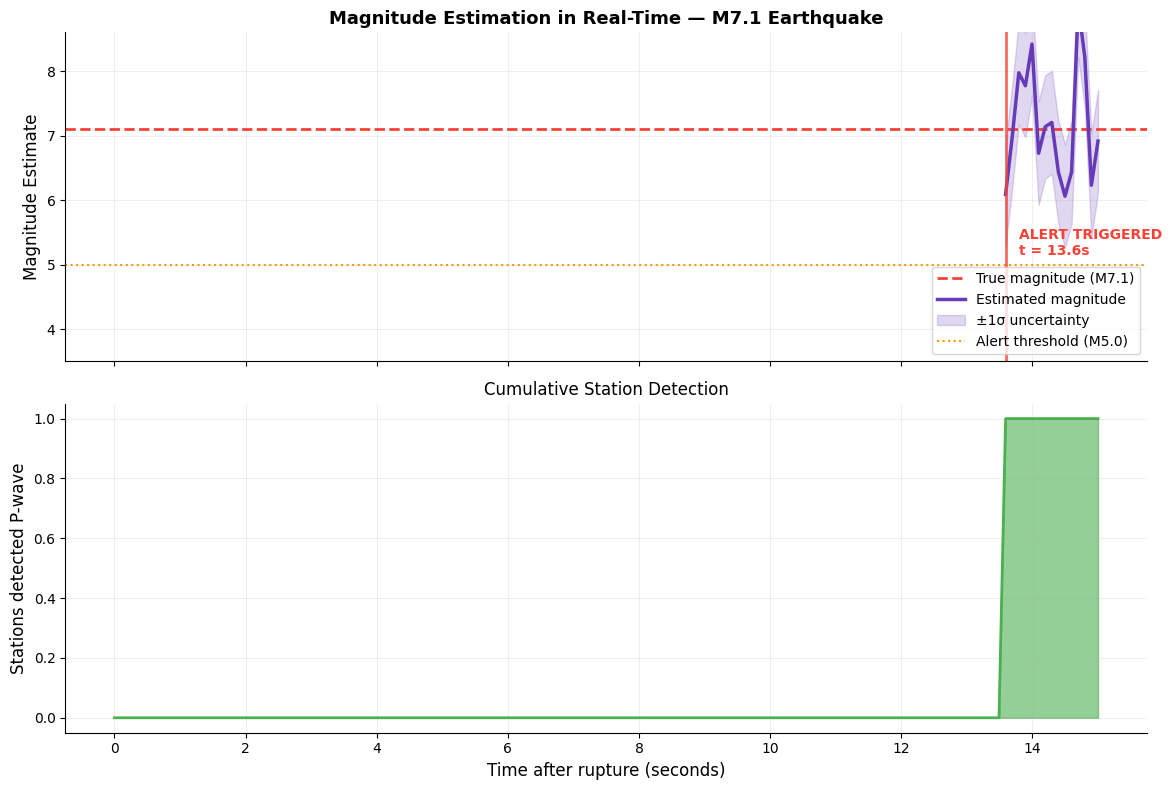

First estimate available at: 13.6 seconds
Alert threshold crossed at: 13.6 seconds


In [6]:
# Simulate magnitude estimation improving over time as more stations detect P-wave
time_axis = np.linspace(0, 15, 150)   # 0 to 15 seconds after rupture
true_magnitude = EARTHQUAKE_MAGNITUDE

estimates = []
n_detected_list = []

for t in time_axis:
    n_detected = int(np.sum(p_arrival <= t))
    n_detected_list.append(n_detected)
    if n_detected >= 1:
        # Uncertainty decreases as more stations report (simplified model)
        uncertainty = 0.8 / np.sqrt(max(n_detected, 1))
        np.random.seed(int(t*10))  # reproducible noise
        estimates.append(true_magnitude + np.random.normal(0, uncertainty))
    else:
        estimates.append(np.nan)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), facecolor='white', sharex=True)

# --- Top panel: magnitude estimate over time ---
ax1.axhline(true_magnitude, color=RED, lw=2, ls='--', label=f'True magnitude (M{true_magnitude})')
ax1.plot(time_axis, estimates, color=PURPLE, lw=2.5, label='Estimated magnitude')

# Uncertainty band
valid = ~np.isnan(estimates)
est_arr = np.array(estimates)
n_arr = np.array(n_detected_list)
sigma = np.where(n_arr >= 1, 0.8 / np.sqrt(np.maximum(n_arr,1)), np.nan)
ax1.fill_between(time_axis, est_arr - sigma, est_arr + sigma,
                  alpha=0.2, color=PURPLE, label='±1σ uncertainty')

# Alert threshold line
ALERT_THRESHOLD = 5.0
ax1.axhline(ALERT_THRESHOLD, color=ORANGE, lw=1.5, ls=':', label=f'Alert threshold (M{ALERT_THRESHOLD})')

# Mark when alert is first triggered
trigger_times = [t for t, e in zip(time_axis, estimates)
                 if not np.isnan(e) and e >= ALERT_THRESHOLD]
if trigger_times:
    ax1.axvline(trigger_times[0], color=RED, lw=2, alpha=0.8)
    ax1.text(trigger_times[0]+0.2, ALERT_THRESHOLD+0.15,
             f'ALERT TRIGGERED\nt = {trigger_times[0]:.1f}s',
             fontsize=10, color=RED, fontweight='bold')

ax1.set_ylabel('Magnitude Estimate', fontsize=12)
ax1.set_title(f'Magnitude Estimation in Real-Time — M{true_magnitude} Earthquake', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='lower right')
ax1.set_ylim(3.5, true_magnitude + 1.5)
ax1.grid(True, alpha=0.2)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# --- Bottom panel: stations detected ---
ax2.fill_between(time_axis, n_detected_list, color=GREEN, alpha=0.6)
ax2.plot(time_axis, n_detected_list, color=GREEN, lw=2)
ax2.set_xlabel('Time after rupture (seconds)', fontsize=12)
ax2.set_ylabel('Stations detected P-wave', fontsize=12)
ax2.set_title('Cumulative Station Detection', fontsize=12)
ax2.grid(True, alpha=0.2)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'First estimate available at: {time_axis[~np.isnan(estimates)][0]:.1f} seconds')
if trigger_times:
    print(f'Alert threshold crossed at: {trigger_times[0]:.1f} seconds')

---
## Part 4 — Warning Time by Distance

**How many seconds of warning does a person get?**

Warning time = (Distance / S-wave speed) − (Alert generation time + Dissemination delay)

People very close to the epicentre may receive **no warning at all** — the S-wave arrives before the alert can be issued. This is the irreducible limitation of earthquake EWS.

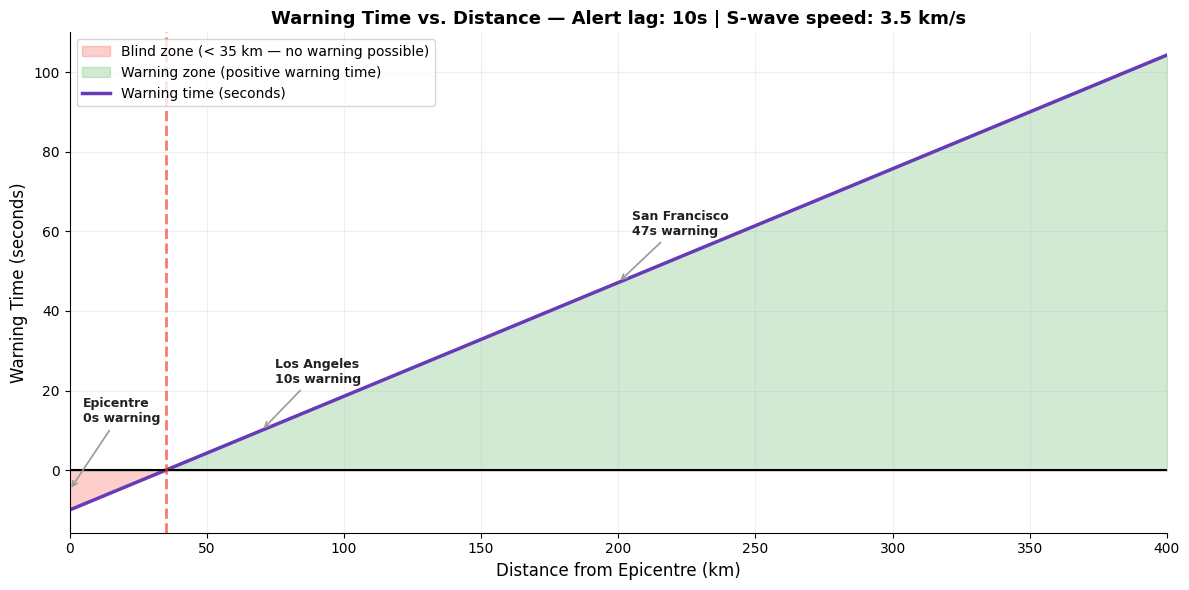

Blind zone radius: 35.0 km (no warning possible inside this radius)
At 70 km (Los Angeles): 10.0 seconds warning
At 200 km (San Francisco): 47.1 seconds warning


In [7]:
# ── PARAMETERS ──────────────────────────────────────────────────────────
ALERT_GENERATION_TIME = 8.0    # seconds from rupture to alert issuance
DISSEMINATION_DELAY   = 2.0    # seconds for SMS/app delivery
S_WAVE_SPEED          = 3.5    # km/s
# ────────────────────────────────────────────────────────────────────────

total_alert_lag = ALERT_GENERATION_TIME + DISSEMINATION_DELAY
distances = np.linspace(0, 400, 400)  # 0 to 400 km from epicentre

s_wave_arrival = distances / S_WAVE_SPEED  # when S-wave arrives
warning_time = s_wave_arrival - total_alert_lag  # positive = warning before shaking

# Blind zone: where S-wave arrives before alert can be delivered
blind_zone_km = total_alert_lag * S_WAVE_SPEED

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

# Shade blind zone (negative warning time)
ax.fill_between(distances, np.minimum(warning_time, 0), 0,
                color=RED, alpha=0.25, label=f'Blind zone (< {blind_zone_km:.0f} km — no warning possible)')
# Warning time zone
ax.fill_between(distances, np.maximum(warning_time, 0), 0,
                color=GREEN, alpha=0.25, label='Warning zone (positive warning time)')

ax.plot(distances, warning_time, color=PURPLE, lw=2.5, label='Warning time (seconds)')
ax.axhline(0, color='black', lw=1.5)
ax.axvline(blind_zone_km, color=RED, lw=2, ls='--', alpha=0.7)

# Annotate key cities (Ridgecrest scenario)
cities = [('Epicentre', 0), ('Los Angeles', 70), ('San Francisco', 200), ('Portland', 420)]
for city, d in cities:
    if d <= 400:
        wt = d/S_WAVE_SPEED - total_alert_lag
        ax.annotate(f'{city}\n{max(wt,0):.0f}s warning',
                    xy=(d, max(wt,-5)), xytext=(d+5, max(wt,0)+12),
                    fontsize=9, color=DARK, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#999', lw=1.2))

ax.set_xlabel('Distance from Epicentre (km)', fontsize=12)
ax.set_ylabel('Warning Time (seconds)', fontsize=12)
ax.set_title(f'Warning Time vs. Distance — Alert lag: {total_alert_lag:.0f}s | S-wave speed: {S_WAVE_SPEED} km/s',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim(0, 400)

plt.tight_layout()
plt.show()

print(f'Blind zone radius: {blind_zone_km:.1f} km (no warning possible inside this radius)')
print(f'At 70 km (Los Angeles): {max(70/S_WAVE_SPEED - total_alert_lag, 0):.1f} seconds warning')
print(f'At 200 km (San Francisco): {max(200/S_WAVE_SPEED - total_alert_lag, 0):.1f} seconds warning')

---
## 🧠 Reflection Questions

Answer these in your Moodle journal or discuss with your group:

1. In Part 4, change `ALERT_GENERATION_TIME` from 8 to 3 seconds. How does the blind zone change? What would be needed to achieve this faster alert?

2. The diagram shows that people very close to the epicentre receive **no warning**. What should the public education programme tell these people to do given they will never receive an alert in time?

3. In Part 3, the magnitude estimate is noisy at the start and stabilises later. If you had to choose between issuing an alert at 4 seconds (noisy estimate) vs. 8 seconds (stable estimate), what would you choose, and why? Does your answer depend on how far away the population is?

---
*DigiHaz Module 5 — Notebook 1 of 3 | github.com/Digihaz/early-warning-system-workshop*